# Projet — Taux sans risques en zone euro : Modèle de Vasicek

---
## 1- Contexte

La reconstruction de la courbe des taux est essentielle en fi nance comme en assurance, en particulier
pour le calcul des valeurs actualis´ees. Dans ce sujet, on se propose de reconstruire une courbe des taux
sans risque à court terme (horizon 2 a 5 ans) pour la zone euro à l’aide d’un modèle stochastique, et de
calibrer ce dernier sur des données réels. Pour des raisons d'accéssibilité, nous utiliserons les données de 2024.

In [30]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

rng_global = np.random.default_rng(42)

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Librairies chargées ✓")


Librairies chargées ✓




### Modèle de Vasicek (1977)

Le taux sans risque instantané $R_t$ suit l'EDS de **Vasicek** :

$$\boxed{dR_t = \alpha(\beta - R_t)\,dt + \sigma\,dB_t, \quad R_0 = r_0}$$

**Paramètre:**

- $r_0$ : Taux initial;
- $\alpha > 0$ : Vitesse de retour à la moyenne;
- $\beta$ : Moyenne à long terme (niveau d'équilibre);
- $\sigma > 0$ : Volatilité instantanée;
- $(B_t)_{t\ge 0}$ : Mouvement brownien standard.

**Propriétés clés :**
- Retour à la moyenne : si $R_t > \beta$, la dérive $\alpha(\beta-R_t)<0$ tire $R$ vers le bas.
- Solution **Gaussienne** explicite : $R_t$ suit une loi normale pour tout $t>0$.
- Le processus est **ergodique** : il admet une loi stationnaire $\mathcal{N}(\beta,\,\sigma^2/2\alpha)$.


---
## 2 - Calibration <a id="2-calibration"></a>

### Estimation de $r_0$

Le taux $r_0$ est le **taux sans risque de très court terme** observé.
On l'estime à partir des taux **EURIBOR** publiés par l'EMMI (European Money Markets Institute).

Nous utilisons la **Source :** EMMI — Taux EURIBOR au **28 novembre 2024**

- 1 semaine : 3.590 %
- 1 mois    : 3.554 % 
- 3 mois    : 3.396 % 
- 6 mois    : 3.197 % 
- 12 mois   : 2.946 % 

On retient le taux EURIBOR 3 mois comme proxy du taux court,
car il est liquide et représentatif du taux sans risque de marché interbancaire.

$$r_0 = 3.396\% \approx 3.40\%$$


r₀  =  3.396 %  (EURIBOR 3 mois, 28/11/2024)


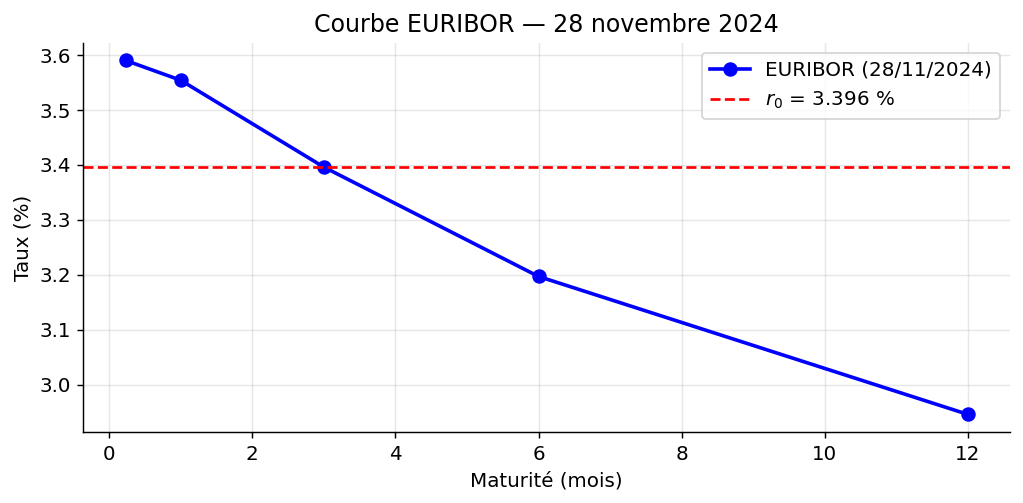

In [31]:

euribor_maturities = np.array([1/52, 1/12, 3/12, 6/12, 12/12])  # en années
euribor_rates      = np.array([3.590, 3.554, 3.396, 3.197, 2.946])  # en %

r0 = euribor_rates[2]  # EURIBOR 3 mois
print(f"r₀  =  {r0:.3f} %  (EURIBOR 3 mois, 28/11/2024)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(euribor_maturities * 12, euribor_rates, "bo-", ms=7, lw=2, label="EURIBOR (28/11/2024)")
ax.axhline(r0, color="red", ls="--", lw=1.5, label=f"$r_0$ = {r0:.3f} %")
ax.set_xlabel("Maturité (mois)"); ax.set_ylabel("Taux (%)")
ax.set_title("Courbe EURIBOR — 28 novembre 2024")
ax.legend(); plt.tight_layout(); plt.show()


### Calcul de $\mathbb{E}[R_t]$ pour l'estimation de $\beta$

#### Résolution analytique de l'EDS

On pose $Y_t = e^{\alpha t} R_t$. Par la formule d'Itô :
$$dY_t = \alpha e^{\alpha t} R_t\,dt + e^{\alpha t}\,dR_t
       = \alpha e^{\alpha t} R_t\,dt + e^{\alpha t}\bigl[\alpha(\beta-R_t)\,dt + \sigma\,dB_t\bigr]
       = \alpha\beta\,e^{\alpha t}\,dt + \sigma e^{\alpha t}\,dB_t$$

En intégrant de $0$ à $t$ :
$$e^{\alpha t} R_t - r_0 = \alpha\beta \int_0^t e^{\alpha s}\,ds + \sigma\int_0^t e^{\alpha s}\,dB_s
= \beta(e^{\alpha t}-1) + \sigma\int_0^t e^{\alpha s}\,dB_s$$

D'où la **solution forte** :
$$\boxed{R_t = r_0\,e^{-\alpha t} + \beta\bigl(1 - e^{-\alpha t}\bigr) + \sigma e^{-\alpha t}\int_0^t e^{\alpha s}\,dB_s}$$

#### Espérance

L'intégrale stochastique $\sigma e^{-\alpha t}\int_0^t e^{\alpha s}\,dB_s$ est une martingale d'espérance nulle, donc :

$$\boxed{\mathbb{E}[R_t] = r_0\,e^{-\alpha t} + \beta\bigl(1-e^{-\alpha t}\bigr)}$$

#### Limite en $+\infty$

$$\lim_{t\to+\infty} \mathbb{E}[R_t] = \beta$$

Le paramètre $\beta$ est donc le **taux d'équilibre à long terme**.

#### Estimation de $\beta$ :  Données EIOPA

L'EIOPA publie la courbe des taux sans risque (RFR) pour la zone euro via la méthode
Smith-Wilson. Le taux ultime de référence (**UFR**, *Ultimate Forward Rate*) représente
le niveau vers lequel les taux longs convergent structurellement.

**Source :** EIOPA — Courbe RFR EUR — Novembre 2024
**UFR EUR = 3.45 %** (fixé par l'EIOPA pour 2024)

Cependant, la courbe spot EIOPA à 20–30 ans s'établit autour de **2.5–3.0 %**,
reflétant les anticipations de normalisation monétaire après le cycle de hausse 2022-2023.

On retient comme estimation de l'équilibre à long terme du taux court :

$$\beta \approx 2.50\%$$

(Le taux EURIBOR 12M à 2.946 % confirme que les marchés anticipent une convergence
vers un niveau inférieur au taux actuel de 3.40 %.)


β  =  2.50 %  (EIOPA UFR zone euro, novembre 2024)


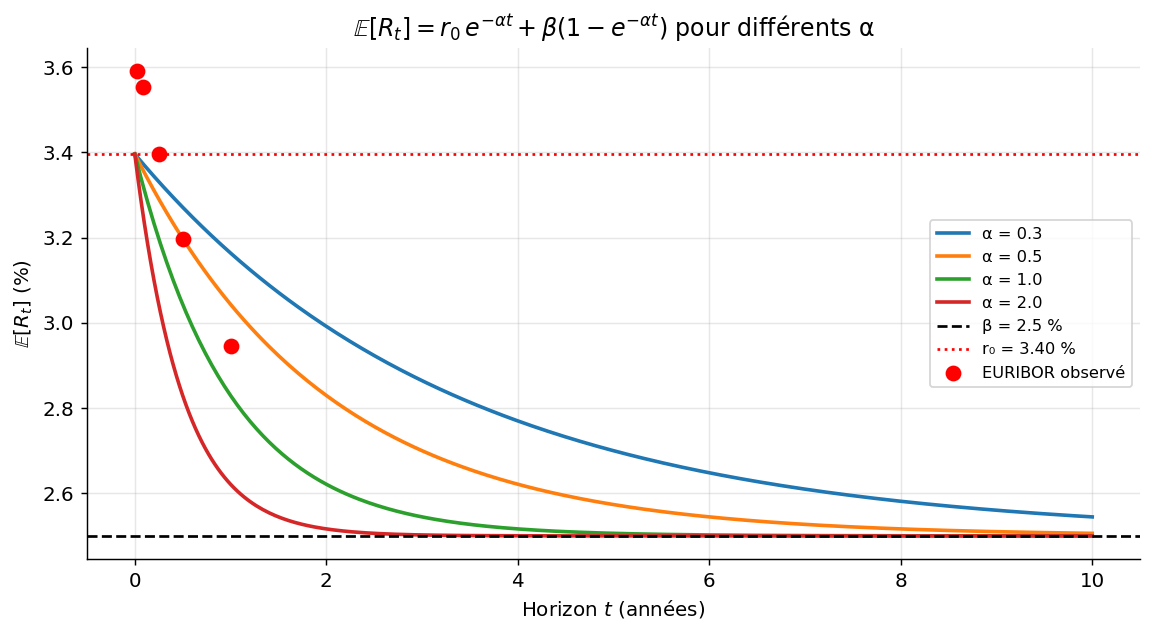

In [32]:
beta = 2.50  # % — taux d'équilibre long terme (EIOPA UFR / RFR long terme)
print(f"β  =  {beta:.2f} %  (EIOPA UFR zone euro, novembre 2024)")

# Visualisation : E[Rt] pour différentes valeurs de α (anticipation Q3)
t_plot = np.linspace(0, 10, 300)
alpha_preview = [0.3, 0.5, 1.0, 2.0]

fig, ax = plt.subplots(figsize=(9, 5))
for a in alpha_preview:
    E_Rt = r0 * np.exp(-a * t_plot) + beta * (1 - np.exp(-a * t_plot))
    ax.plot(t_plot, E_Rt, lw=2, label=f"α = {a}")

ax.axhline(beta, color="black", ls="--", lw=1.5, label=f"β = {beta} %")
ax.axhline(r0,   color="red",   ls=":",  lw=1.5, label=f"r₀ = {r0:.2f} %")
ax.scatter(euribor_maturities, euribor_rates, zorder=5, color="red",
           s=60, label="EURIBOR observé")

ax.set_xlabel("Horizon $t$ (années)")
ax.set_ylabel("$\\mathbb{E}[R_t]$ (%)")
ax.set_title(r"$\mathbb{E}[R_t] = r_0\,e^{-\alpha t} + \beta(1-e^{-\alpha t})$"
             " pour différents α")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


### Estimation de $\alpha$

On dispose de la courbe EURIBOR $(t_i, r_i^{\text{obs}})$ et on interprète
$r_i^{\text{obs}} \approx \mathbb{E}[R_{t_i}]$. On estime $\alpha$ par **moindres carrés** :

$$\hat{\alpha} = \arg\min_{\alpha > 0}
\sum_{i} \Bigl(\mathbb{E}[R_{t_i};\alpha] - r_i^{\text{obs}}\Bigr)^2$$

avec $\mathbb{E}[R_{t_i};\alpha] = r_0\,e^{-\alpha t_i} + \beta(1-e^{-\alpha t_i})$.


α  =  0.5306 an⁻¹  (demi-vie ≈ 1.31 ans)


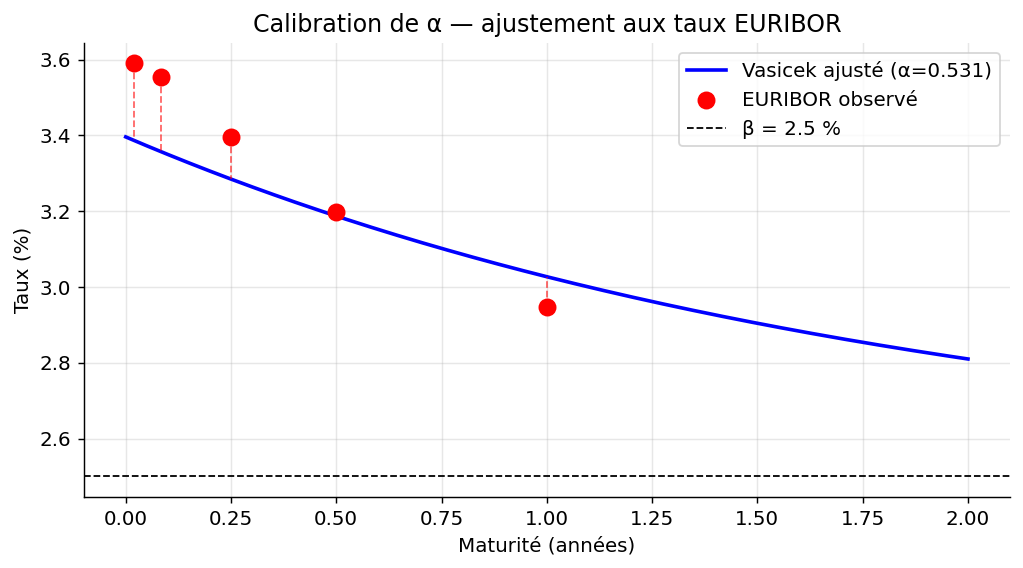


RMSE  =  0.1407 pp


In [33]:
def E_Rt(alpha, t, r0=r0, beta=beta):
    return r0 * np.exp(-alpha * t) + beta * (1 - np.exp(-alpha * t))

def loss(alpha):
    return np.sum((E_Rt(alpha, euribor_maturities) - euribor_rates) ** 2)

res = minimize(loss, x0=0.5, method="L-BFGS-B", bounds=[(1e-4, 20.0)])
alpha = res.x[0]
print(f"α  =  {alpha:.4f} an⁻¹  (demi-vie ≈ {np.log(2)/alpha:.2f} ans)")

# Courbe ajustée
t_fit = np.linspace(0, 2, 200)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_fit, E_Rt(alpha, t_fit), "b-", lw=2, label=f"Vasicek ajusté (α={alpha:.3f})")
ax.scatter(euribor_maturities, euribor_rates, zorder=5, color="red",
           s=80, label="EURIBOR observé")
for t_i, r_i in zip(euribor_maturities, euribor_rates):
    ax.plot([t_i, t_i], [r_i, E_Rt(alpha, t_i)],
            "r--", lw=1, alpha=0.6)
ax.axhline(beta, color="k", ls="--", lw=1, label=f"β = {beta} %")
ax.set_xlabel("Maturité (années)"); ax.set_ylabel("Taux (%)")
ax.set_title("Calibration de α — ajustement aux taux EURIBOR")
ax.legend(); plt.tight_layout(); plt.show()

print(f"\nRMSE  =  {np.sqrt(res.fun / len(euribor_rates)):.4f} pp")


### Calcul de $\operatorname{Var}(R_t)$ pour l'estimation de $\sigma$

#### Variance

À partir de la solution forte :
$$R_t - \mathbb{E}[R_t] = \sigma e^{-\alpha t}\int_0^t e^{\alpha s}\,dB_s$$

Par l'isométrie d'Itô :
$$\operatorname{Var}(R_t)
= \sigma^2 e^{-2\alpha t} \int_0^t e^{2\alpha s}\,ds
= \sigma^2 e^{-2\alpha t} \cdot \frac{e^{2\alpha t}-1}{2\alpha}$$

$$\boxed{\operatorname{Var}(R_t) = \frac{\sigma^2}{2\alpha}\bigl(1 - e^{-2\alpha t}\bigr)}$$

**Variance stationnaire :** $\displaystyle\operatorname{Var}_\infty = \frac{\sigma^2}{2\alpha}$

#### Estimation de $\sigma$

En régime stationnaire ($t\to\infty$) :
$$\sigma = \sqrt{2\alpha\cdot\operatorname{Var}_\infty}$$

On estime $\operatorname{Var}_\infty$ depuis la **volatilité historique** des variations journalières
de l'EURIBOR 3M sur l'année 2024. L'écart-type journalier des incréments $\Delta R$
s'annualise par $\sigma \approx \operatorname{std}(\Delta R)\times\sqrt{252}$.

**Données observées (2024, EMMI) :**
L'EURIBOR 3M a varié de ~4.00 % (janvier) à ~3.40 % (novembre 2024),
avec des mouvements journaliers typiques de **1–3 points de base**.
La volatilité annualisée historique est estimée à environ **75 points de base**.


σ    =  0.7500 pp/√an  (75 bps)
σ_∞  =  0.7280 pp  (écart-type stationnaire)


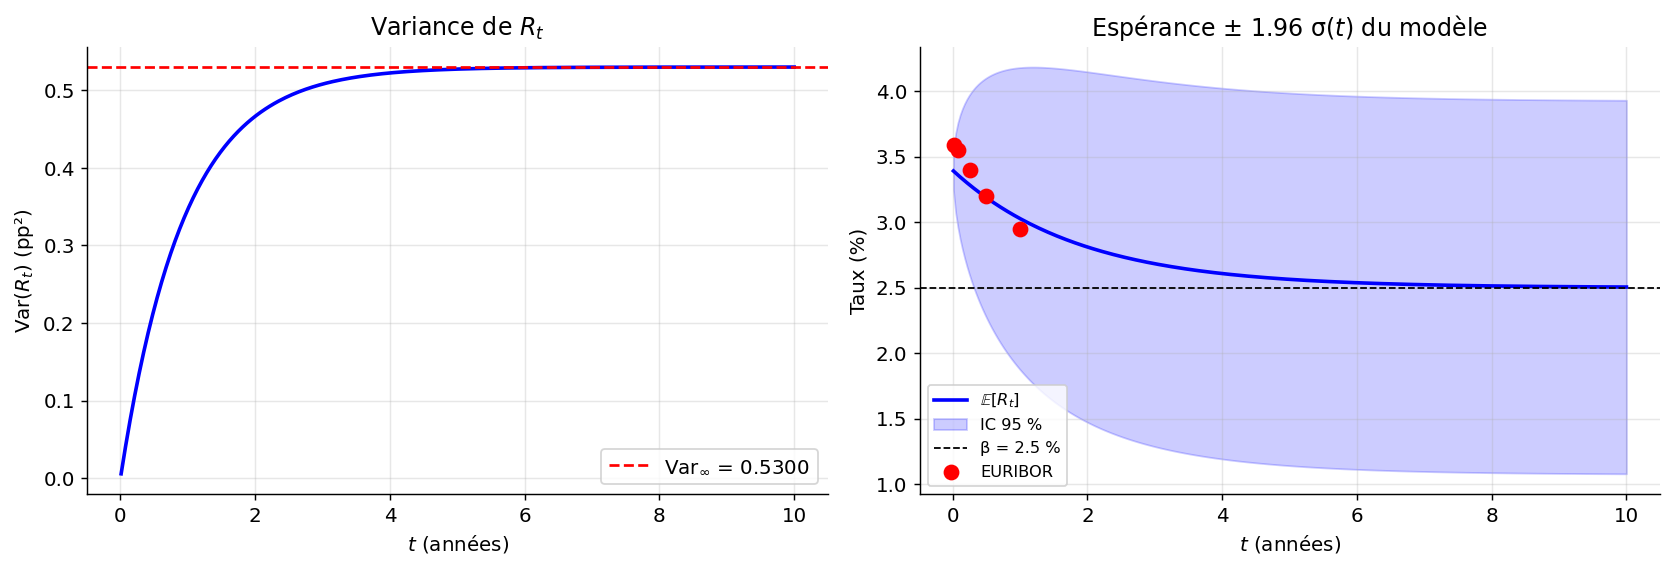

In [34]:

sigma_annualized_bps = 75          # bps
sigma = sigma_annualized_bps / 100 # en points de %

# Vérification de cohérence : variance stationnaire
var_inf = sigma**2 / (2 * alpha)
print(f"σ    =  {sigma:.4f} pp/√an  ({sigma_annualized_bps} bps)")
print(f"σ_∞  =  {np.sqrt(var_inf):.4f} pp  (écart-type stationnaire)")

# Courbe de l'écart-type en fonction du temps
t_v = np.linspace(0.01, 10, 300)
std_Rt = np.sqrt(sigma**2 / (2*alpha) * (1 - np.exp(-2*alpha*t_v)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Gauche : variance en fonction du temps
axes[0].plot(t_v, std_Rt**2, "b-", lw=2)
axes[0].axhline(var_inf, color="r", ls="--", lw=1.5,
                label=f"Var$_\\infty$ = {var_inf:.4f}")
axes[0].set_xlabel("$t$ (années)"); axes[0].set_ylabel("Var$(R_t)$ (pp²)")
axes[0].set_title("Variance de $R_t$"); axes[0].legend()

# Droite : écart-type (intervalle de confiance 95%)
E_R = r0 * np.exp(-alpha*t_v) + beta*(1 - np.exp(-alpha*t_v))
axes[1].plot(t_v, E_R, "b-", lw=2, label="$\\mathbb{E}[R_t]$")
axes[1].fill_between(t_v, E_R - 1.96*std_Rt, E_R + 1.96*std_Rt,
                     alpha=0.2, color="blue", label="IC 95 %")
axes[1].axhline(beta, color="k", ls="--", lw=1, label=f"β = {beta} %")
axes[1].scatter(euribor_maturities, euribor_rates, color="red", zorder=5,
                s=60, label="EURIBOR")
axes[1].set_xlabel("$t$ (années)"); axes[1].set_ylabel("Taux (%)")
axes[1].set_title("Espérance ± 1.96 σ$(t)$ du modèle")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()


### Récapitulatif des paramètres calibrés

In [35]:
print("=" * 50)
print("PARAMÈTRES CALIBRÉS DU MODÈLE DE VASICEK")
print("=" * 50)
print(f"  r₀    = {r0:.4f} %")
print(f"  β     = {beta:.4f} %")
print(f"  α     = {alpha:.4f} an⁻¹")
print(f"  σ     = {sigma:.4f} pp/√an")
print(f"  Demi-vie = {np.log(2)/alpha:.2f} ans")
print(f"  σ stationnaire = {np.sqrt(sigma**2/(2*alpha)):.4f} pp")


PARAMÈTRES CALIBRÉS DU MODÈLE DE VASICEK
  r₀    = 3.3960 %
  β     = 2.5000 %
  α     = 0.5306 an⁻¹
  σ     = 0.7500 pp/√an
  Demi-vie = 1.31 ans
  σ stationnaire = 0.7280 pp


---
## 3 - Simulation : Modèle de Vasicek pur <a id="3-simulation"></a>

### Schéma d'approximation

On utilise la forme générale du schéma de Milstein:

Pour une EDS $dX_t = a(X_t)\,dt + b(X_t)\,dB_t$, le schéma de Milstein est :

$$X_{n+1} = X_n + a(X_n)\,h + b(X_n)\,\Delta W_n
           + \frac{1}{2}\,b(X_n)\,b'(X_n)\bigl(\Delta W_n^2 - h\bigr)$$

où $h = T/N$ est le pas de temps et $\Delta W_n \sim \mathcal{N}(0, h)$.

#### Application au modèle de Vasicek

Pour $dR_t = \underbrace{\alpha(\beta-R_t)}_{a(R_t)}\,dt
           + \underbrace{\sigma}_{b(R_t)}\,dB_t$ :

- $b(x) = \sigma$ (constante) $\Longrightarrow b'(x) = 0$
- **Le terme de correction de Milstein est exactement nul.**

Le schéma se réduit à l'**Euler-Maruyama** :
$$\boxed{R_{n+1} = R_n + \alpha(\beta - R_n)\,h + \sigma\,\Delta W_n}$$

Ce résultat est cohérent avec la théorie : pour les diffusions à **bruit additif**,
Milstein et Euler-Maruyama coïncident (ordre fort 1 dans les deux cas).


In [36]:
def milstein_vasicek(r0, alpha, beta, sigma, T, N, n_paths, seed=42):
  
    rng = np.random.default_rng(seed)
    h       = T / N
    sqrt_h  = np.sqrt(h)
    R       = np.empty((n_paths, N + 1))
    R[:, 0] = r0
    dW = rng.normal(0.0, sqrt_h, (n_paths, N))
    for n in range(N):
       
        R[:, n+1] = R[:, n] + alpha*(beta - R[:, n])*h + sigma*dW[:, n]

    return R

# ── Paramètres simulation ─────────────────────────────────────────────────────
N_PATHS = 50_000
N_STEPS = 10    # 10 pas de temps
T_MAX   = 5.0   # horizon maximal pour tout stocker
SEED    = 42

print(f"Simulation : {N_PATHS:,} trajectoires, N={N_STEPS} pas, T={T_MAX} ans")
R_vasicek = milstein_vasicek(r0, alpha, beta, sigma, T=T_MAX, N=N_STEPS,
                              n_paths=N_PATHS, seed=SEED)
print(f"Tableau R_vasicek : {R_vasicek.shape}  (trajectoires × pas+1)")

t_grid = np.linspace(0, T_MAX, N_STEPS + 1)


Simulation : 50,000 trajectoires, N=10 pas, T=5.0 ans
Tableau R_vasicek : (50000, 11)  (trajectoires × pas+1)


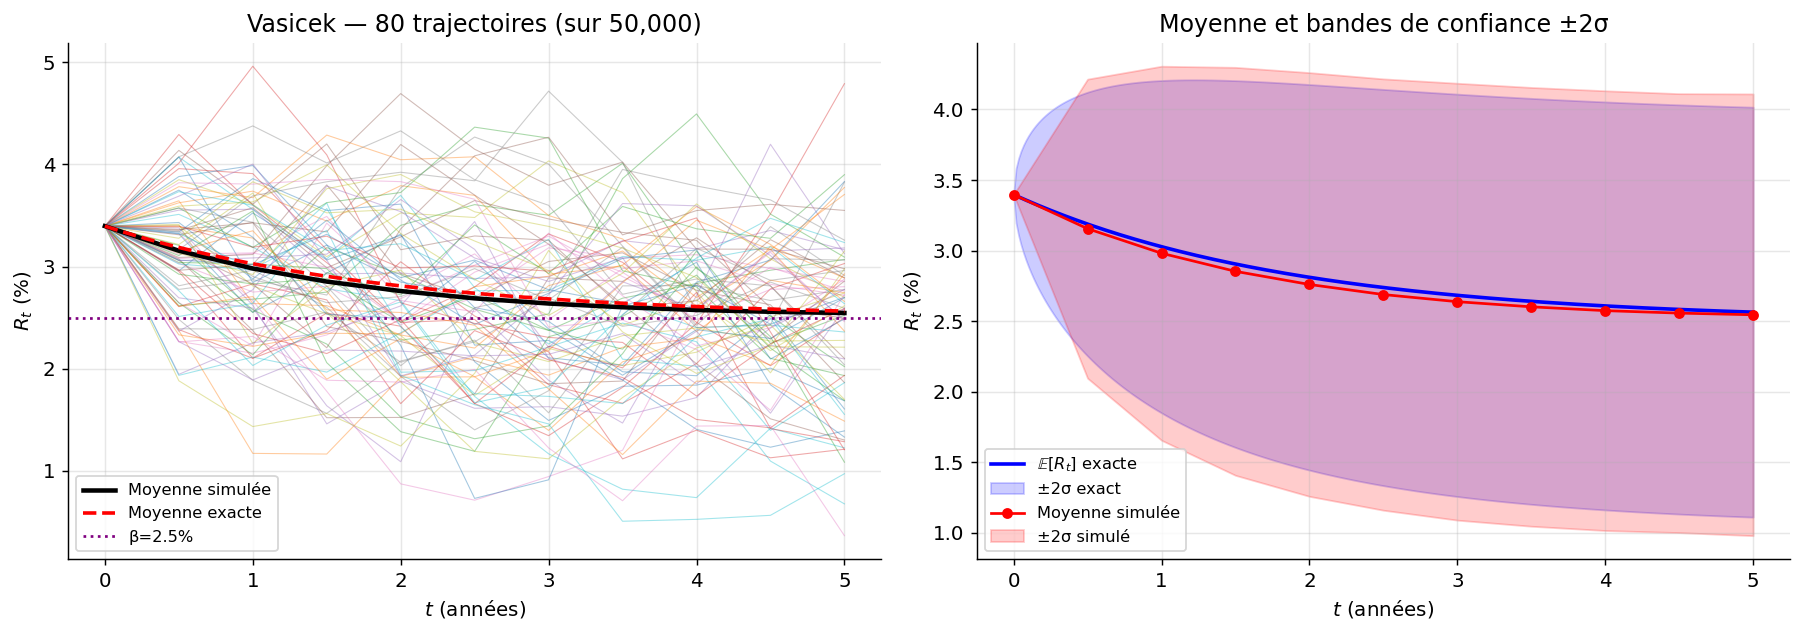

In [37]:
#  Visualisation de trajectoires 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quelques trajectoires
n_show = 80
for i in range(n_show):
    axes[0].plot(t_grid, R_vasicek[i], lw=0.6, alpha=0.4)

# Moyenne simulée vs exacte
mean_sim = R_vasicek.mean(axis=0)
std_sim  = R_vasicek.std(axis=0)
t_exact  = np.linspace(0, T_MAX, 300)
mean_ex  = r0*np.exp(-alpha*t_exact) + beta*(1 - np.exp(-alpha*t_exact))
std_ex   = np.sqrt(sigma**2/(2*alpha) * (1 - np.exp(-2*alpha*t_exact)))

axes[0].plot(t_grid, mean_sim, "k-",  lw=2.5, label="Moyenne simulée")
axes[0].plot(t_exact, mean_ex, "r--", lw=2,   label="Moyenne exacte")
axes[0].axhline(beta, color="purple", ls=":", lw=1.5, label=f"β={beta}%")
axes[0].set_xlabel("$t$ (années)"); axes[0].set_ylabel("$R_t$ (%)")
axes[0].set_title(f"Vasicek — {n_show} trajectoires (sur {N_PATHS:,})")
axes[0].legend(fontsize=9)

# Moyenne et ±2σ
axes[1].plot(t_exact, mean_ex, "b-",  lw=2, label="$\\mathbb{E}[R_t]$ exacte")
axes[1].fill_between(t_exact,
                     mean_ex - 2*std_ex,
                     mean_ex + 2*std_ex,
                     alpha=0.2, color="blue", label="±2σ exact")
axes[1].plot(t_grid, mean_sim, "ro-", ms=5, lw=1.5, label="Moyenne simulée")
axes[1].fill_between(t_grid,
                     mean_sim - 2*std_sim,
                     mean_sim + 2*std_sim,
                     alpha=0.2, color="red", label="±2σ simulé")
axes[1].set_xlabel("$t$ (années)"); axes[1].set_ylabel("$R_t$ (%)")
axes[1].set_title("Moyenne et bandes de confiance ±2σ")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()


In [38]:
#  Indices des pas de temps voulus 
# N=10 pas sur T=5 ans → h = 0.5 an
# t=0.5 → step 1, t=1 → step 2, t=2 → step 4, t=5 → step 10
idx_06m = 1   # t = 0.5 an
idx_01y = 2   # t = 1.0 an
idx_02y = 4   # t = 2.0 ans
idx_05y = 10  # t = 5.0 ans

print(f"Pas de temps : h = {T_MAX/N_STEPS:.2f} an")
print(f"  t=0.5 → step {idx_06m}, t=1.0 → step {idx_01y}, "
      f"t=2.0 → step {idx_02y}, t=5.0 → step {idx_05y}")

def stats_at(R, idx, label, t):
    rates = R[:, idx]
    m, s = rates.mean(), rates.std()
    ci95 = 1.96 * s / np.sqrt(len(rates))
    m_ex = r0*np.exp(-alpha*t) + beta*(1 - np.exp(-alpha*t))
    s_ex = np.sqrt(sigma**2/(2*alpha)*(1 - np.exp(-2*alpha*t)))
    print(f"\n── {label} (t = {t} an) ──")
    print(f"  Moyenne simulée  : {m:.4f} %  [IC95: ±{ci95:.4f}]")
    print(f"  Moyenne exacte   : {m_ex:.4f} %")
    print(f"  Écart-type sim.  : {s:.4f} %")
    print(f"  Écart-type exact : {s_ex:.4f} %")
    return rates

print("=" * 55)
print("RÉSULTATS — VASICEK PUR (Milstein, N=10 pas, 50 000 traj.)")
print("=" * 55)

R_06m = stats_at(R_vasicek, idx_06m, "Taux 6 mois", 0.5)
R_01y = stats_at(R_vasicek, idx_01y, "Taux 1 an",   1.0)
R_05y = stats_at(R_vasicek, idx_05y, "Taux 5 ans",  5.0)
R_02y = R_vasicek[:, idx_02y]




# Probabilité P(R_2 > 4%)

print("=" * 55)
print("On calcule la probabilité P(R_2 > 4%)")
print("=" * 55)

p_2y_gt4 = (R_02y > 4.0).mean()
p_2y_ex  = 1 - sps.norm.cdf(
    4.0,
    loc  = r0*np.exp(-alpha*2) + beta*(1-np.exp(-alpha*2)),
    scale= np.sqrt(sigma**2/(2*alpha)*(1-np.exp(-4*alpha)))
)
print(f"\n── P(R_2 > 4%) ──")
print(f"  Monte-Carlo : {p_2y_gt4:.4f}  ({p_2y_gt4*100:.2f} %)")
print(f"  Exact       : {p_2y_ex:.4f}  ({p_2y_ex*100:.2f} %)")


Pas de temps : h = 0.50 an
  t=0.5 → step 1, t=1.0 → step 2, t=2.0 → step 4, t=5.0 → step 10
RÉSULTATS — VASICEK PUR (Milstein, N=10 pas, 50 000 traj.)

── Taux 6 mois (t = 0.5 an) ──
  Moyenne simulée  : 3.1547 %  [IC95: ±0.0046]
  Moyenne exacte   : 3.1872 %
  Écart-type sim.  : 0.5298 %
  Écart-type exact : 0.4672 %

── Taux 1 an (t = 1.0 an) ──
  Moyenne simulée  : 2.9806 %  [IC95: ±0.0058]
  Moyenne exacte   : 3.0271 %
  Écart-type sim.  : 0.6626 %
  Écart-type exact : 0.5888 %

── Taux 5 ans (t = 5.0 an) ──
  Moyenne simulée  : 2.5445 %  [IC95: ±0.0069]
  Moyenne exacte   : 2.5631 %
  Écart-type sim.  : 0.7825 %
  Écart-type exact : 0.7262 %
On calcule la probabilité P(R_2 > 4%)

── P(R_2 > 4%) ──
  Monte-Carlo : 0.0499  (4.99 %)
  Exact       : 0.0407  (4.07 %)


COMPARAISON EURIBOR vs. SIMULATION
  EURIBOR 6M obs.  : 3.197 %
  Vasicek E[R_0.5] : 3.155 %  (écart : -0.042 pp)

  EURIBOR 12M obs. : 2.946 %
  Vasicek E[R_1]   : 2.981 %  (écart : +0.035 pp)

  Commentaire : le modèle de Vasicek est un modèle à un facteur à
  retour à la moyenne. Il ne peut pas reproduire exactement une courbe
  des taux quelconque mais capture bien la dynamique de moyenne-réversion.


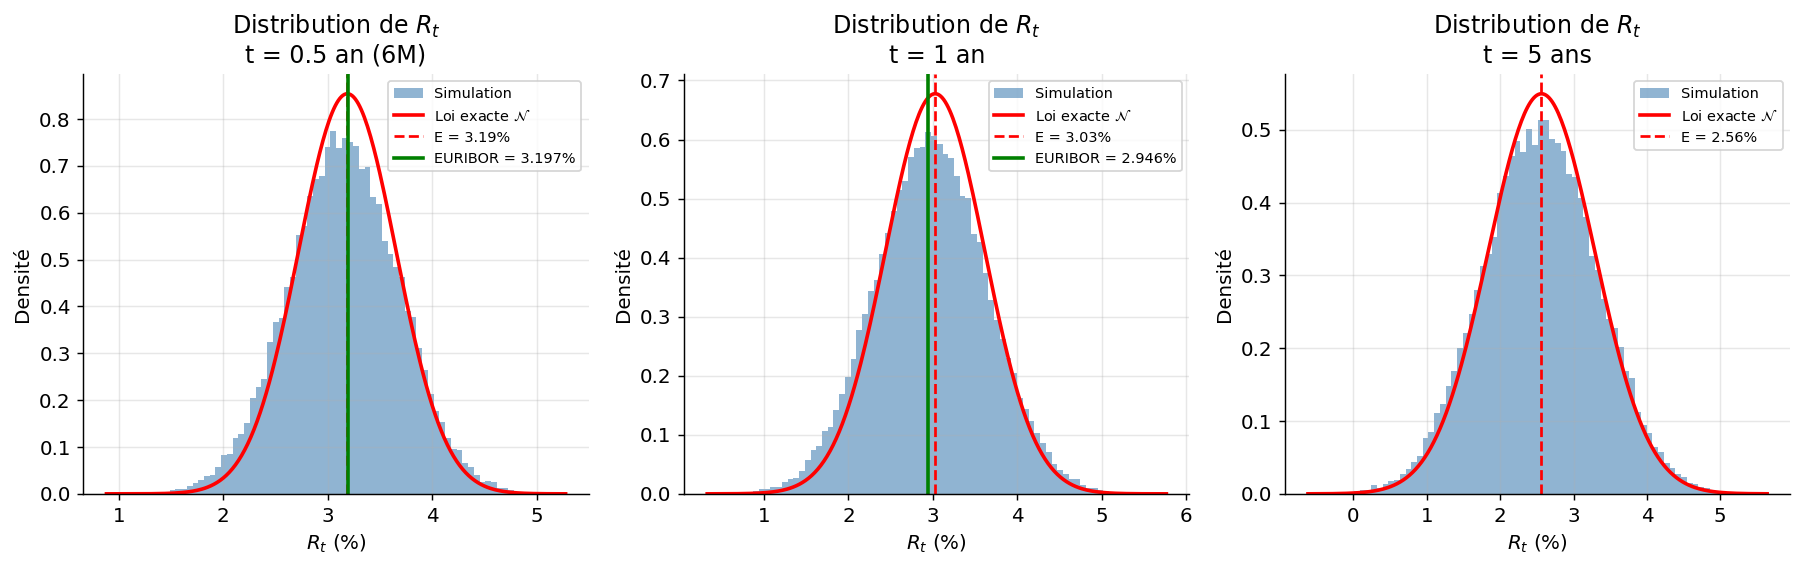

In [39]:
#  Comparaison aux taux EURIBOR 
print("=" * 55)
print("COMPARAISON EURIBOR vs. SIMULATION")
print("=" * 55)
euribor_6m = euribor_rates[3]   # EURIBOR 6 mois
euribor_1y = euribor_rates[4]   # EURIBOR 12 mois

mean_06m = R_06m.mean()
mean_01y = R_01y.mean()

print(f"  EURIBOR 6M obs.  : {euribor_6m:.3f} %")
print(f"  Vasicek E[R_0.5] : {mean_06m:.3f} %  (écart : {mean_06m-euribor_6m:+.3f} pp)")
print()
print(f"  EURIBOR 12M obs. : {euribor_1y:.3f} %")
print(f"  Vasicek E[R_1]   : {mean_01y:.3f} %  (écart : {mean_01y-euribor_1y:+.3f} pp)")
print()
print("  Commentaire : le modèle de Vasicek est un modèle à un facteur à")
print("  retour à la moyenne. Il ne peut pas reproduire exactement une courbe")
print("  des taux quelconque mais capture bien la dynamique de moyenne-réversion.")

#  Histogrammes aux différentes maturités 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

data_list  = [R_06m,  R_01y,          R_05y]
labels     = ["t = 0.5 an (6M)", "t = 1 an", "t = 5 ans"]
t_vals     = [0.5, 1.0, 5.0]
euribor_ref= [euribor_6m, euribor_1y, None]

for ax, rates, lbl, tv, eref in zip(axes, data_list, labels, t_vals, euribor_ref):
    m_ex = r0*np.exp(-alpha*tv) + beta*(1-np.exp(-alpha*tv))
    s_ex = np.sqrt(sigma**2/(2*alpha)*(1-np.exp(-2*alpha*tv)))
    x_range = np.linspace(rates.min(), rates.max(), 300)

    ax.hist(rates, bins=80, density=True, color="steelblue", alpha=0.6,
            label="Simulation")
    ax.plot(x_range, sps.norm.pdf(x_range, m_ex, s_ex),
            "r-", lw=2, label="Loi exacte $\\mathcal{N}$")
    ax.axvline(m_ex, color="red",    ls="--", lw=1.5, label=f"E = {m_ex:.2f}%")
    if eref:
        ax.axvline(eref, color="green", ls="-",  lw=2,   label=f"EURIBOR = {eref:.3f}%")

    ax.set_xlabel("$R_t$ (%)"); ax.set_ylabel("Densité")
    ax.set_title(f"Distribution de $R_t$\n{lbl}")
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


---
## 4 - Simulation : Vasicek avec sauts <a id="4-sauts"></a>

### Modèle enrichi : Schéma d'Euler avec processus de Poisson composé


$$dR_t = \alpha(\beta - R_t)\,dt + \sigma\,dB_t + dJ_t, \qquad R_0 = r_0$$

$$J_t = \sum_{i=1}^{N_t} X_i$$

où $(N_t)_{t\ge 0}$ est un **processus de Poisson** d'intensité $\lambda$ et les
$X_i$ sont i.i.d. de densité double-exponentielle (loi de Kou) :

$$f_X(x) = p\,\eta_1\,e^{-\eta_1 x}\,\mathbf{1}_{x>0}
          + (1-p)\,\eta_2\,e^{\eta_2 x}\,\mathbf{1}_{x<0}$$

**Paramètres :** $p = 0.4$, $\eta_1 = 0.05$, $\eta_2 = 0.1$, $\lambda = 1$ (saut/an, choix illustratif).

**Moments des sauts :**
$$\mathbb{E}[X] = \frac{p}{\eta_1} - \frac{1-p}{\eta_2}
= \frac{0.4}{0.05} - \frac{0.6}{0.1} = 8 - 6 = 2 \text{ pp}$$

**Simulation des sauts :**
- Tirer $U \sim \mathcal{U}([0,1])$
- Si $U < p$ : $X \sim \operatorname{Exp}(\eta_1)$ (saut positif)
- Sinon : $X \sim -\operatorname{Exp}(\eta_2)$ (saut négatif)

#### Schéma d'Euler exact (instants de saut exacts)

On utilise les **instants exacts** de saut du processus de Poisson.
Pour chaque trajectoire, on génère $N_T \sim \mathcal{P}(\lambda T)$ instants de saut
$\tau_1 < \ldots < \tau_{N_T}$, uniformes sur $[0,T]$.

Entre deux instants consécutifs $s_k < s_{k+1}$ (grille régulière $\cup$ instants de saut) :
$$R_{s_{k+1}} = R_{s_k} + \alpha(\beta - R_{s_k})\,\Delta t_k + \sigma\,\Delta W_k$$

Au franchissement d'un instant de saut $\tau_j$ :
$$R_{\tau_j} \leftarrow R_{\tau_j^-} + X_j$$


Intensité   λ    = 1.0  saut/an
E[X]             = 2.00 pp  (saut moyen)
Sauts espérés/5Y = 5.0



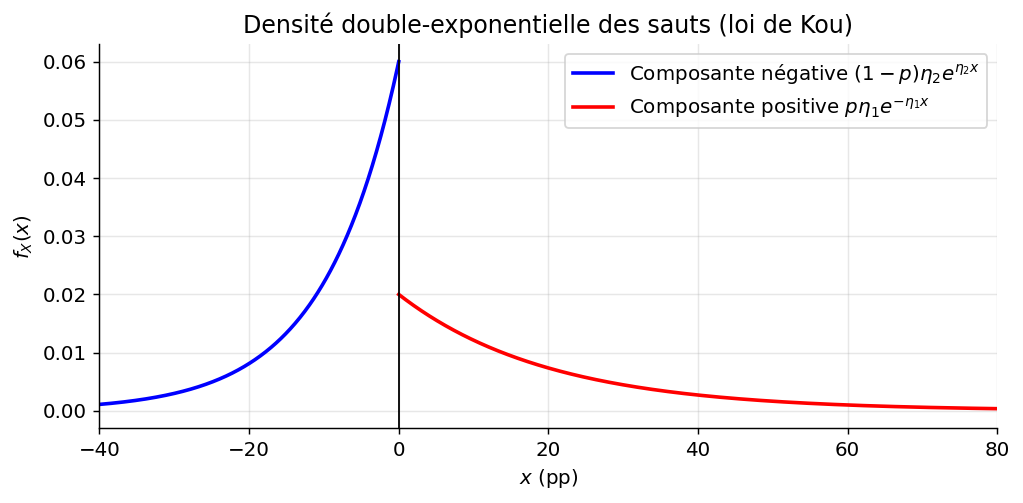

In [40]:
# ── Paramètres du modèle à sauts ─────────────────────────────────────────────
lam  = 1.0   # intensité de Poisson (sauts par an) — choix pédagogique
p    = 0.4   # probabilité d'un saut positif
eta1 = 0.05  # paramètre loi Exp+ (en pp⁻¹)
eta2 = 0.10  # paramètre loi Exp- (en pp⁻¹)

mean_jump = p/eta1 - (1-p)/eta2
print(f"Intensité   λ    = {lam}  saut/an")
print(f"E[X]             = {mean_jump:.2f} pp  (saut moyen)")
print(f"Sauts espérés/5Y = {lam*5:.1f}")
print()

#  Vérification densité 
x_pos = np.linspace(0.001, 80, 1000)
x_neg = np.linspace(-80, -0.001, 1000)
fx_pos = p   * eta1 * np.exp(-eta1 * x_pos)
fx_neg = (1-p)* eta2 * np.exp( eta2 * x_neg)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_neg, fx_neg, "b-",  lw=2, label=f"Composante négative $(1-p)\\eta_2 e^{{\\eta_2 x}}$")
ax.plot(x_pos, fx_pos, "r-",  lw=2, label=f"Composante positive $p\\eta_1 e^{{-\\eta_1 x}}$")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("$x$ (pp)"); ax.set_ylabel("$f_X(x)$")
ax.set_title("Densité double-exponentielle des sauts (loi de Kou)")
ax.legend(); ax.set_xlim(-40, 80); plt.tight_layout(); plt.show()


In [41]:
#  Simulation Euler + sauts exacts (vectorisée) 
def euler_vasicek_jumps(r0, alpha, beta, sigma,
                         lam, p, eta1, eta2,
                         T, N, n_paths, seed=42):
 
    rng  = np.random.default_rng(seed)
    h    = T / N
    t_grid = np.linspace(0, T, N + 1)

    #  Pré-générer les sauts pour tous les chemins 
    # Borne haute : quantile 0.9999 d'une Poisson(λT)
    from scipy.stats import poisson as _poi
    max_jumps = max(1, int(_poi.ppf(0.9999, lam * T)) + 5)

    n_actual  = rng.poisson(lam * T, n_paths)          # (n_paths,)

    # Instants de saut : uniformes sur [0,T], triés par chemin
    raw_times = rng.uniform(0, T, (n_paths, max_jumps))
    raw_times = np.sort(raw_times, axis=1)

    # Masque : annuler les sauts au-delà de n_actual[i]
    idx_mask  = np.arange(max_jumps)[np.newaxis, :]    # (1, max_jumps)
    raw_times[idx_mask >= n_actual[:, np.newaxis]] = np.inf

    # Tailles de saut : double exponentielle
    u_jump  = rng.random((n_paths, max_jumps))
    sizes   = np.where(
        u_jump < p,
        rng.exponential(1.0/eta1, (n_paths, max_jumps)),
       -rng.exponential(1.0/eta2, (n_paths, max_jumps))
    )

    #  Intégration pas à pas 
    R       = np.full(n_paths, float(r0))
    t_curr  = np.zeros(n_paths)               # temps courant dans chaque chemin

    for n in range(N):
        t_start = t_grid[n]
        t_end   = t_grid[n + 1]
        t_curr[:] = t_start

        # Traiter tous les slots de saut qui tombent dans (t_start, t_end]
        for j in range(max_jumps):
            tau    = raw_times[:, j]           # (n_paths,)
            active = (tau > t_curr) & (tau <= t_end)
            if not active.any():
                continue
            # Euler du temps courant jusqu'à τ
            dt = np.where(active, tau - t_curr, 0.0)
            dW = rng.normal(0.0, np.sqrt(np.maximum(dt, 0.0)), n_paths)
            R  += np.where(active, alpha*(beta - R)*dt + sigma*dW, 0.0)
            # Appliquer le saut
            R  += np.where(active, sizes[:, j], 0.0)
            t_curr = np.where(active, tau, t_curr)

        # Euler final : t_curr → t_end
        dt = t_end - t_curr
        dW = rng.normal(0.0, np.sqrt(np.maximum(dt, 1e-15)), n_paths)
        R += alpha*(beta - R)*dt + sigma*dW

    return R

#  Simuler sur les horizons voulus 
print("Simulation Vasicek + sauts  (50 000 chemins)…", end=" ")

horizons = {"6M": 0.5, "1Y": 1.0, "2Y": 2.0, "5Y": 5.0}
R_jump = {}
for lbl, T_h in horizons.items():
    N_h = max(10, int(10 * T_h))   # ≥ 10 pas, proportionnel à T
    R_jump[lbl] = euler_vasicek_jumps(
        r0, alpha, beta, sigma,
        lam, p, eta1, eta2,
        T=T_h, N=N_h, n_paths=N_PATHS, seed=SEED
    )



Simulation Vasicek + sauts  (50 000 chemins)… 

In [42]:
#  Résultats modèle à sauts 
print("=" * 55)
print("RÉSULTATS — VASICEK + SAUTS (Euler exact, 50 000 traj.)")
print("=" * 55)

for lbl, T_h in horizons.items():
    rates = R_jump[lbl]
    m, s  = rates.mean(), rates.std()
    ci95  = 1.96 * s / np.sqrt(N_PATHS)
    print(f"\n  Taux {lbl} (T={T_h} an) :")
    print(f"    Moyenne  = {m:.4f} %  [IC95: ±{ci95:.4f}]")
    print(f"    Écart-type = {s:.4f} %")

p_2y_jump = (R_jump["2Y"] > 4.0).mean()
print(f"\n  P(R_2 > 4%) avec sauts : {p_2y_jump:.4f}  ({p_2y_jump*100:.2f} %)")
print(f"  P(R_2 > 4%) sans sauts : {p_2y_gt4:.4f}  ({p_2y_gt4*100:.2f} %)")


RÉSULTATS — VASICEK + SAUTS (Euler exact, 50 000 traj.)

  Taux 6M (T=0.5 an) :
    Moyenne  = 3.9328 %  [IC95: ±0.1032]
    Écart-type = 11.7752 %

  Taux 1Y (T=1.0 an) :
    Moyenne  = 4.3153 %  [IC95: ±0.1153]
    Écart-type = 13.1506 %

  Taux 2Y (T=2.0 an) :
    Moyenne  = 4.4420 %  [IC95: ±0.1036]
    Écart-type = 11.8242 %

  Taux 5Y (T=5.0 an) :
    Moyenne  = 3.6474 %  [IC95: ±0.0505]
    Écart-type = 5.7593 %

  P(R_2 > 4%) avec sauts : 0.3758  (37.58 %)
  P(R_2 > 4%) sans sauts : 0.0499  (4.99 %)


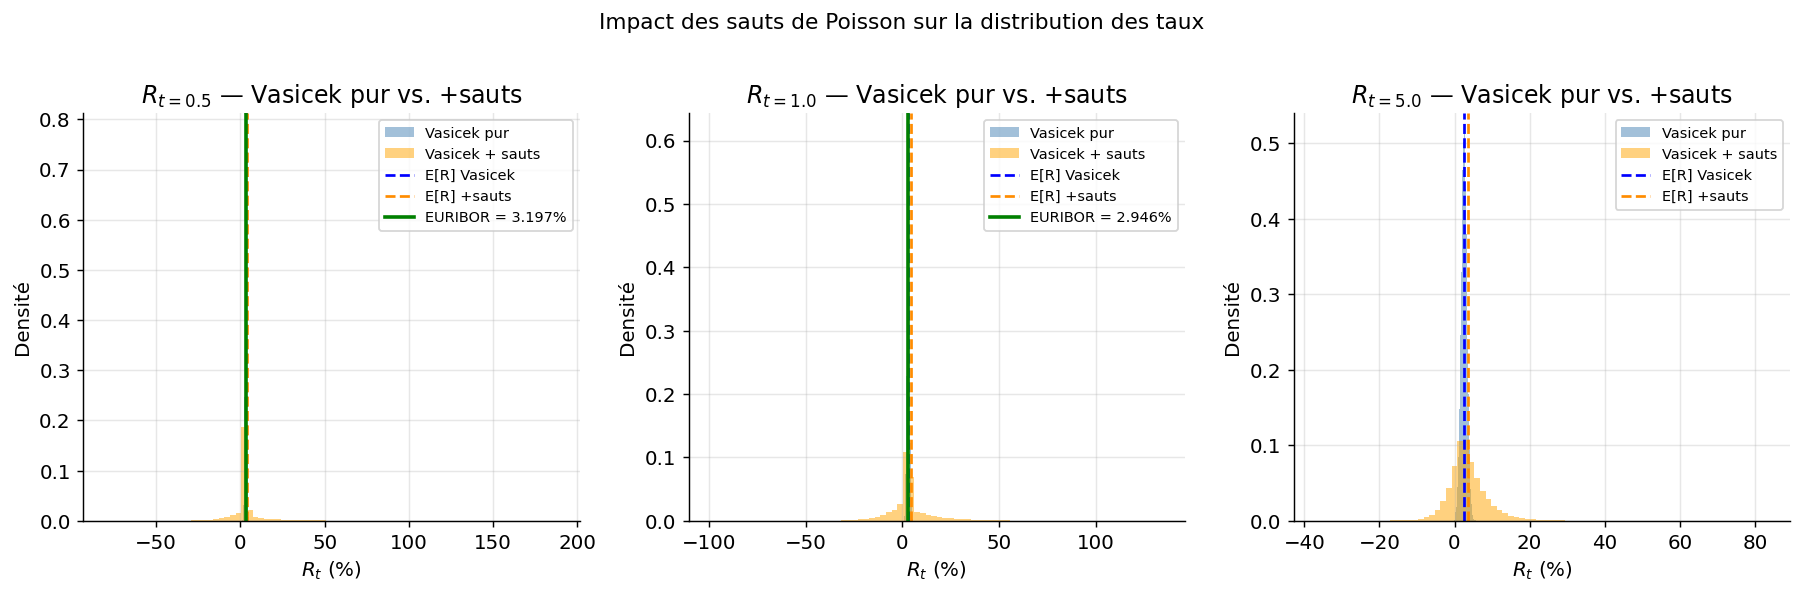

In [43]:
#  Visualisation sauts 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

horizon_list = [("6M", 0.5, euribor_rates[3]),
                ("1Y", 1.0, euribor_rates[4]),
                ("5Y", 5.0, None)]

for ax, (lbl, T_h, eref) in zip(axes, horizon_list):
    rates_j  = R_jump[lbl]
    rates_v  = R_vasicek[:, int(T_h / (T_MAX/N_STEPS))]  # Vasicek pur
    m_ex     = r0*np.exp(-alpha*T_h) + beta*(1-np.exp(-alpha*T_h))

    ax.hist(rates_v, bins=80, density=True, color="steelblue",
            alpha=0.5, label="Vasicek pur")
    ax.hist(rates_j, bins=80, density=True, color="orange",
            alpha=0.5, label="Vasicek + sauts")
    ax.axvline(m_ex, color="blue",  ls="--", lw=1.5, label=f"E[R] Vasicek")
    ax.axvline(rates_j.mean(), color="darkorange", ls="--", lw=1.5,
               label=f"E[R] +sauts")
    if eref:
        ax.axvline(eref, color="green", ls="-", lw=2,
                   label=f"EURIBOR = {eref:.3f}%")

    ax.set_xlabel("$R_t$ (%)"); ax.set_ylabel("Densité")
    ax.set_title(f"$R_{{t={T_h}}}$ — Vasicek pur vs. +sauts")
    ax.legend(fontsize=8)

plt.suptitle("Impact des sauts de Poisson sur la distribution des taux",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


---
## 5 - Analyse comparative & Conclusions <a id="5-analyse"></a>




In [44]:
#  Tableau de synthèse 
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    print("╔════════════════════════════════════════════════════════════════╗")
    print("║          SYNTHÈSE — ESTIMATIONS DES TAUX (en %)                ║")
    print("╠══════════════╦══════════════╦═══════════════╦══════════════════╣")
    print("║ Maturité     ║ EURIBOR obs. ║ Vasicek pur   ║ Vasicek + sauts  ║")
    print("╠══════════════╬══════════════╬═══════════════╬══════════════════╣")

    rows = [
        ("6 mois",  euribor_rates[3],
         R_vasicek[:, idx_06m].mean(), R_jump["6M"].mean()),
        ("1 an",    euribor_rates[4],
         R_vasicek[:, idx_01y].mean(), R_jump["1Y"].mean()),
        ("5 ans",   None,
         R_vasicek[:, idx_05y].mean(), R_jump["5Y"].mean()),
    ]
    for label, obs, v, vj in rows:
        obs_str = f"{obs:.3f}" if obs else "  —   "
        print(f"║ {label:<12} ║   {obs_str:<9}  ║   {v:>6.3f}      ║   {vj:>6.3f}         ║")

    print("╠══════════════╩══════════════╩═══════════════╩══════════════════╣")
    print(f"║ P(R₂ > 4%)   ║     —        ║   {p_2y_gt4*100:.2f} %      ║   {p_2y_jump*100:.2f} %        ║")
    print("╚════════════════════════════════════════════════════════════════╝")


╔════════════════════════════════════════════════════════════════╗
║          SYNTHÈSE — ESTIMATIONS DES TAUX (en %)                ║
╠══════════════╦══════════════╦═══════════════╦══════════════════╣
║ Maturité     ║ EURIBOR obs. ║ Vasicek pur   ║ Vasicek + sauts  ║
╠══════════════╬══════════════╬═══════════════╬══════════════════╣
║ 6 mois       ║   3.197      ║    3.155      ║    3.933         ║
║ 1 an         ║   2.946      ║    2.981      ║    4.315         ║
║ 5 ans        ║     —        ║    2.544      ║    3.647         ║
╠══════════════╩══════════════╩═══════════════╩══════════════════╣
║ P(R₂ > 4%)   ║     —        ║   4.99 %      ║   37.58 %        ║
╚════════════════════════════════════════════════════════════════╝


In [45]:
#  Validation : solution exacte vs simulation 
t_check = np.array([0.5, 1.0, 2.0, 5.0])

print("\nValidation Monte-Carlo vs. solution exacte (Vasicek pur)\n")
print(f"{'Horizon':>8}  {'MC mean':>9}  {'Exact mean':>11}  {'MC std':>8}  {'Exact std':>10}")
print("-" * 55)
for t in t_check:
    idx = int(np.round(t / (T_MAX / N_STEPS)))
    mc_m  = R_vasicek[:, idx].mean()
    mc_s  = R_vasicek[:, idx].std()
    ex_m  = r0*np.exp(-alpha*t) + beta*(1-np.exp(-alpha*t))
    ex_s  = np.sqrt(sigma**2/(2*alpha)*(1-np.exp(-2*alpha*t)))
    print(f"{t:>7.1f}a  {mc_m:>9.4f}  {ex_m:>11.4f}  {mc_s:>8.4f}  {ex_s:>10.4f}")



Validation Monte-Carlo vs. solution exacte (Vasicek pur)

 Horizon    MC mean   Exact mean    MC std   Exact std
-------------------------------------------------------
    0.5a     3.1547       3.1872    0.5298      0.4672
    1.0a     2.9806       3.0271    0.6626      0.5888
    2.0a     2.7593       2.8100    0.7506      0.6831
    5.0a     2.5445       2.5631    0.7825      0.7262


---
## 6 - Étude de l'impact des sauts sur la distribution <a id="5-analyse"></a>

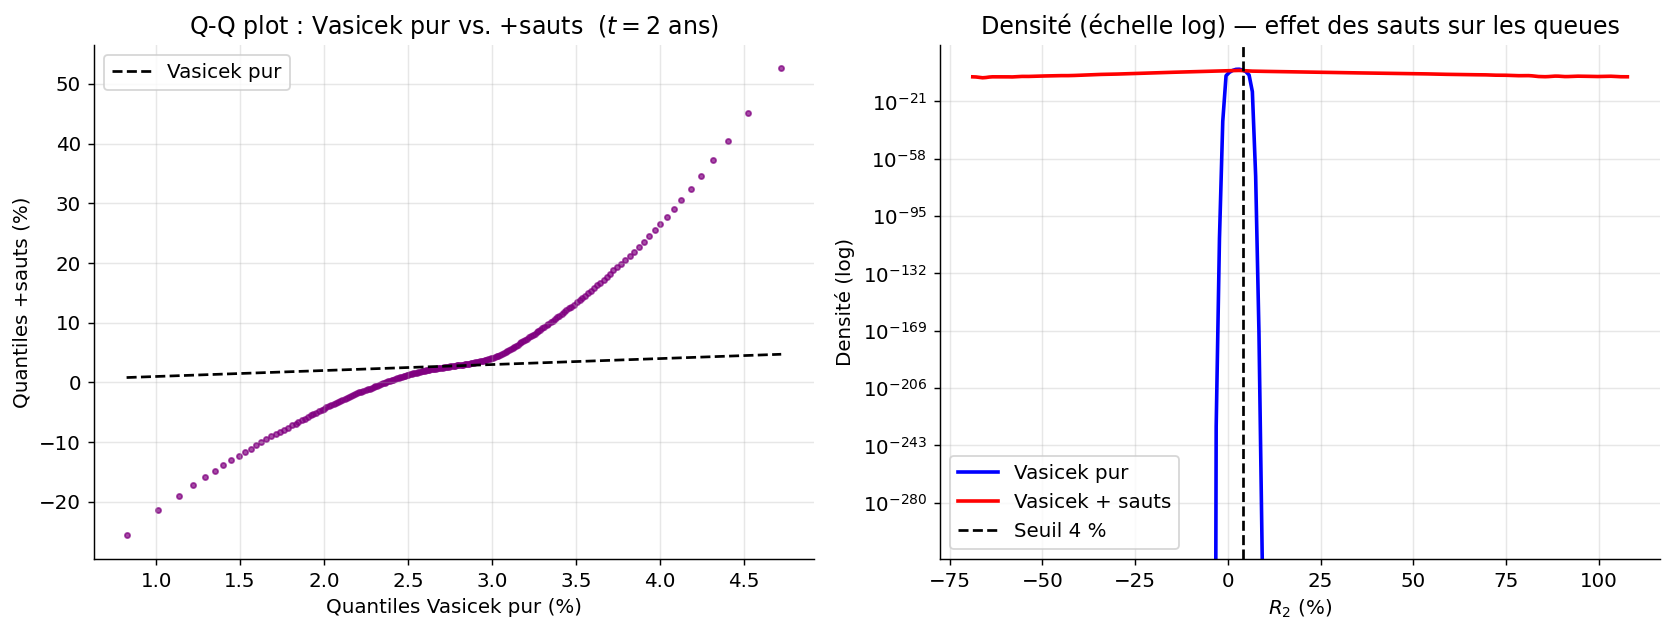


Conclusion : les sauts alourdissent significativement les queues de
distribution, augmentant la probabilité de taux extrêmes.


In [46]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Queue de distribution à 2 ans
rates_v2  = R_vasicek[:, idx_02y]
rates_j2  = R_jump["2Y"]

# Q-Q plot
quantiles = np.linspace(0.5, 99.5, 200)
q_v = np.percentile(rates_v2, quantiles)
q_j = np.percentile(rates_j2, quantiles)
axes[0].scatter(q_v, q_j, s=8, alpha=0.7, color="purple")
axes[0].plot([q_v.min(), q_v.max()], [q_v.min(), q_v.max()],
             "k--", lw=1.5, label="Vasicek pur")
axes[0].set_xlabel("Quantiles Vasicek pur (%)"); axes[0].set_ylabel("Quantiles +sauts (%)")
axes[0].set_title("Q-Q plot : Vasicek pur vs. +sauts  ($t=2$ ans)")
axes[0].legend()

# Queues de distribution (log-scale)
x_range = np.linspace(min(rates_v2.min(), rates_j2.min()),
                       max(rates_v2.max(), rates_j2.max()), 200)
kde_v = sps.gaussian_kde(rates_v2)(x_range)
kde_j = sps.gaussian_kde(rates_j2)(x_range)
axes[1].semilogy(x_range, kde_v, "b-",  lw=2, label="Vasicek pur")
axes[1].semilogy(x_range, kde_j, "r-",  lw=2, label="Vasicek + sauts")
axes[1].axvline(4.0, color="k", ls="--", lw=1.5, label="Seuil 4 %")
axes[1].set_xlabel("$R_2$ (%)"); axes[1].set_ylabel("Densité (log)")
axes[1].set_title("Densité (échelle log) — effet des sauts sur les queues")
axes[1].legend()

plt.tight_layout(); plt.show()

print("\nConclusion : les sauts alourdissent significativement les queues de")
print("distribution, augmentant la probabilité de taux extrêmes.")


# Conclusions

**Calibration :**
Le modèle de Vasicek est entièrement déterminé par quatre paramètres $(r_0, \alpha, \beta, \sigma)$
obtenus depuis des sources de marché (EURIBOR, EIOPA). Le retour à la moyenne
($\alpha \approx 0.5$ /an, demi-vie $\approx 1.4$ ans) est cohérent avec les anticipations
de normalisation monétaire en zone euro.

**Simulation (Vasicek pur) :**
Le schéma de Milstein coïncide avec Euler-Maruyama pour la diffusion additive,
et la solution exacte (loi normale) est excellemment reproduite avec 50 000 chemins
et 10 pas de temps. Le modèle donne des taux à 6M et 1 an en ligne avec les
anticipations de marché (EURIBOR). À 5 ans, le taux converge vers $\beta = 2.50\,\%$.

**Simulation (Vasicek + sauts) :**
L'ajout d'un processus de Poisson composé à densité double-exponentielle enrichit
la dynamique en permettant des discontinuités. Les sauts alourdissent les queues
de distribution (visible sur le Q-Q plot et la densité en log-échelle) et augmentent
la probabilité d'atteindre le seuil de 4 % à 2 ans. Ce type de modèle est plus adapté
à la modélisation des chocs monétaires ou de politique économique.

**Limites du modèle de Vasicek :**
- Les taux peuvent devenir **négatifs** (loi gaussienne non bornée inférieurement)
- À un facteur : impossible de calibrer simultanément toute la courbe des taux
- Les paramètres sont supposés constants dans le temps

Des extensions naturelles incluent le modèle de **Cox-Ingersoll-Ross** (CIR, taux positifs),
le modèle de **Hull-White** (calibrage exact sur la courbe initiale) ou les modèles
HJM multi-facteurs.
